# Ejercicio 1

Implemente el algoritmo de retropropagacion para un perceptr ́on mul-
ticapa de forma que se pueda elegir libremente la cantidad de capas de la red
y de neuronas en cada capa. Pru ́ebelo entrenando una red de estructura apro-
piada para resolver el problema XOR, con sus particiones de entrenamiento y
prueba correspondientes (datos de la Gu ́ıa de trabajos pr ́acticos 1).

Una estructura apropiada para este problema es optar por dos capas:
- Capa oculta con salida no lineal (como una sigmoide simetrica) con dos neuronas
- Capa de salida de una sola neurona con salida no lineal (con sigmoide simetrica)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from algorithms.neural_network import neural_network
from algorithms.auxiliares import *




In [2]:
ruta_data = os.path.abspath('../data')

X_train, y_train = cargar_datos_csv(os.path.join(ruta_data, 'XOR_trn.csv'))
X_test, y_test = cargar_datos_csv(os.path.join(ruta_data, 'XOR_tst.csv'))


model = neural_network(
    layers_config = [(2, 'symmetry sigmoid'), (1, 'symmetry sigmoid')],
    size_input = X_train.shape[1],
    max_epoch=100,
    learning_rate=0.01,
    error_threshold=10)

model.fit(X_train, y_train)

y_pred = model.transform(X_test)

print(model.score(X_test, y_test))


Época: 0 - Errorcito: 2011.4912819520487
Época: 1 - Errorcito: 2005.8421022764087
Época: 2 - Errorcito: 2004.801466724415
Época: 3 - Errorcito: 2004.443313539527
Época: 4 - Errorcito: 2004.0888833062065
Época: 5 - Errorcito: 2003.6065478426815
Época: 6 - Errorcito: 2002.9489209038104
Época: 7 - Errorcito: 2002.0621049019314
Época: 8 - Errorcito: 2000.8623783247606
Época: 9 - Errorcito: 1999.217439834649
Época: 10 - Errorcito: 1996.914137590697
Época: 11 - Errorcito: 1993.5968234341747
Época: 12 - Errorcito: 1988.6432592621945
Época: 13 - Errorcito: 1980.8942934257425
Época: 14 - Errorcito: 1968.0253872524859
Época: 15 - Errorcito: 1945.0472242877186
Época: 16 - Errorcito: 1900.7576337627388
Época: 17 - Errorcito: 1810.2245211474524
Época: 18 - Errorcito: 1626.5163086175185
Época: 19 - Errorcito: 1305.890432135815
Época: 20 - Errorcito: 904.1396968528303
Época: 21 - Errorcito: 565.9335878694471
Época: 22 - Errorcito: 349.5273568164879
Época: 23 - Errorcito: 224.27133856848644
Época: 24 

In [3]:
print(y_test.shape, y_pred.shape)
print(np.hstack((y_test, y_pred)))

(200, 1) (200, 1)
[[-1.         -0.94331112]
 [ 1.          0.9194158 ]
 [-1.         -0.94394609]
 [-1.         -0.9422422 ]
 [-1.         -0.94237047]
 [-1.         -0.942727  ]
 [ 1.          0.91775745]
 [ 1.          0.91995082]
 [-1.         -0.94285183]
 [ 1.          0.92141894]
 [-1.         -0.94393762]
 [-1.         -0.94308104]
 [ 1.          0.9190095 ]
 [ 1.          0.91746853]
 [ 1.          0.91711938]
 [-1.         -0.9434846 ]
 [-1.         -0.94311444]
 [ 1.          0.91919941]
 [ 1.          0.92947556]
 [-1.         -0.94391278]
 [ 1.          0.92198976]
 [-1.         -0.94169121]
 [ 1.          0.91814745]
 [-1.         -0.94330203]
 [ 1.          0.92270826]
 [ 1.          0.91618395]
 [ 1.          0.91568747]
 [-1.         -0.94348385]
 [-1.         -0.94287748]
 [-1.         -0.94325203]
 [-1.         -0.94333699]
 [ 1.          0.92391112]
 [-1.         -0.94387523]
 [ 1.          0.924955  ]
 [-1.         -0.94346769]
 [-1.         -0.94344006]
 [-1.     

Inspeccionando un poco como se comporta el modelo podemos ver la curva del error

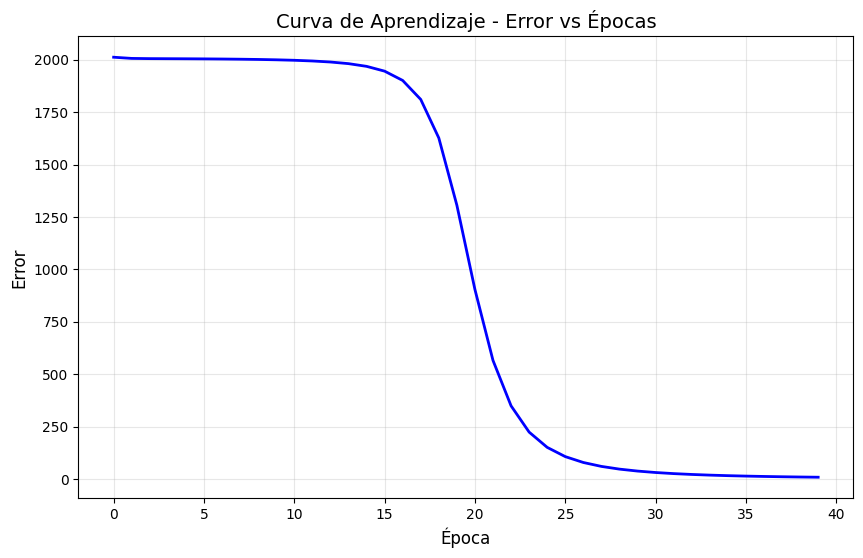

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(model.epoch_error, color='blue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

Vamos a inspeccionar que superficie de decision se tiene

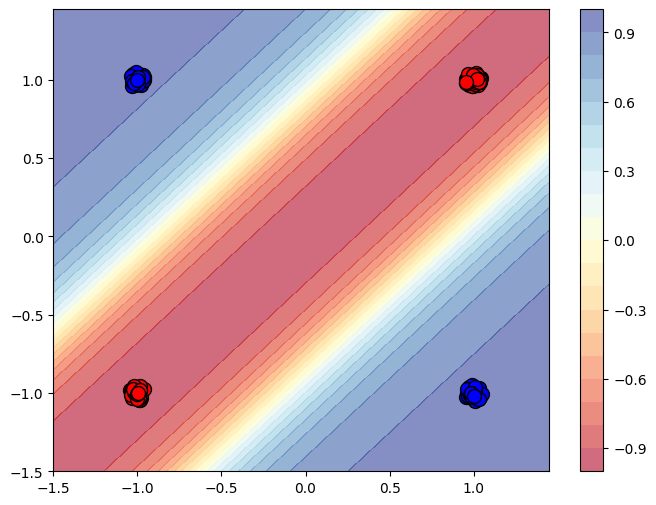

In [11]:
x_min, x_max = -1.5, 1.5
y_min, y_max = -1.5, 1.5

resolucion = 0.05 #delta x y delta y para hacer la maya

xx=np.arange(x_min, x_max, resolucion)
yy=np.arange(y_min, y_max, resolucion)

#creamos la malla 2d
X_malla, Y_malla = np.meshgrid(xx, yy)

#para cada punto de la malla predecimos su clase

puntos_aplanados = np.c_[X_malla.ravel(), Y_malla.ravel()] #los aplana para recorrerlos

predicciones = []
for punto in puntos_aplanados:
    punto_fila = punto.reshape(1,-1) #nuestra red espera una fila
    salida = model.transform(punto_fila)
    predicciones.append(salida.flatten()[0]) #retorna array nuestra salida

#convertimos a una malla
Z = np.array(predicciones).reshape(X_malla.shape)

plt.figure(figsize=(8, 6))
cont = plt.contourf(X_malla, Y_malla, Z, levels=20, cmap='RdYlBu', alpha=0.6)
plt.colorbar(cont)
for i in range(len(X_test)):
    if y_test[i] == 1:
        plt.scatter(X_test[i, 0], X_test[i, 1], color='blue', s=100, edgecolors='black')
    else:
        plt.scatter(X_test[i, 0], X_test[i, 1], color='red', s=100, edgecolors='black')


